Steps:

1. Clone the github repo
2. Download the dependencies and dataset
3. Run the EDA code block
4. Run the classification code block
5. Do not run the train code block. The model weight is already saved in github, /content/skin-lesion-classifier/models/efficientnetb4-v2/efficientnet_b4_v3_epoch_15.pth (to update)



In [ ]:
#for cloning the github
!git clone -b init-skin-lesion-intsys https://github.com/venz-ochoa/skin-lesion-classifier.git
%cd skin-lesion-classifier

#we move to the initial branch first
!git checkout init-skin-lesion-intsys

Cloning into 'skin-lesion-classifier'...
remote: Enumerating objects: 189, done.
remote: Counting objects: 100% (89/89), done.
remote: Compressing objects: 100% (70/70), done.
remote: Total 189 (delta 27), reused 61 (delta 16), pack-reused 100 (from 3)
Receiving objects: 100% (189/189), 568.78 MiB | 14.61 MiB/s, done.
Resolving deltas: 100% (59/59), done.
Filtering content: 100% (3/3), 203.05 MiB | 6.24 MiB/s, done.
/content/skin-lesion-classifier/skin-lesion-classifier/skin-lesion-classifier
Already on 'init-skin-lesion-intsys'
Your branch is up to date with 'origin/init-skin-lesion-intsys'.


In [ ]:
#to download the dependencies and datasets
!python /content/skin-lesion-classifier/source/download_data.py

cSkin Lesion Project Terminal
	[1] Download Dependencies
	[2] Download Datasets
	[3] Download Dependencies & Datasets

Enter: 3

Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
100% 5.20G/5.20G [04:52<00:00, 19.1MB/s]

Downloaded HAM10000 Successfully!

Dataset URL: https://www.kaggle.com/datasets/andrewmvd/isic-2019
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)
100% 9.10G/9.10G [08:13<00:00, 19.8MB/s]

Downloaded ISIC 2019 Successfully!


---- HAM10000 Summary ----
Total Images: 10015

Class Counts:
cell_type
Nevus                   6705
Melanoma                1113
Benign Keratosis        1099
Basal Cell Carcinoma     514
Actinic Keratoses        327
Vascular Lesions         142
Dermatofibroma           115
Name: count, dtype: int64

Top 5 Localization Sites:
localization
back               2192
lower extremity    2077
trunk              1404
upper extremity    1118
abdomen            1022
Name: count, dtype: int64
------------------------



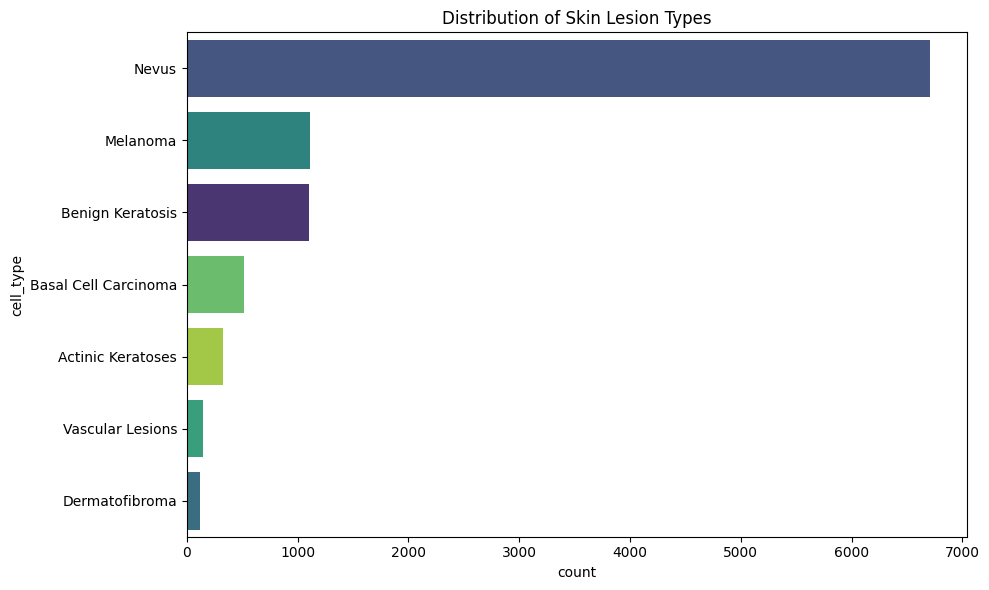

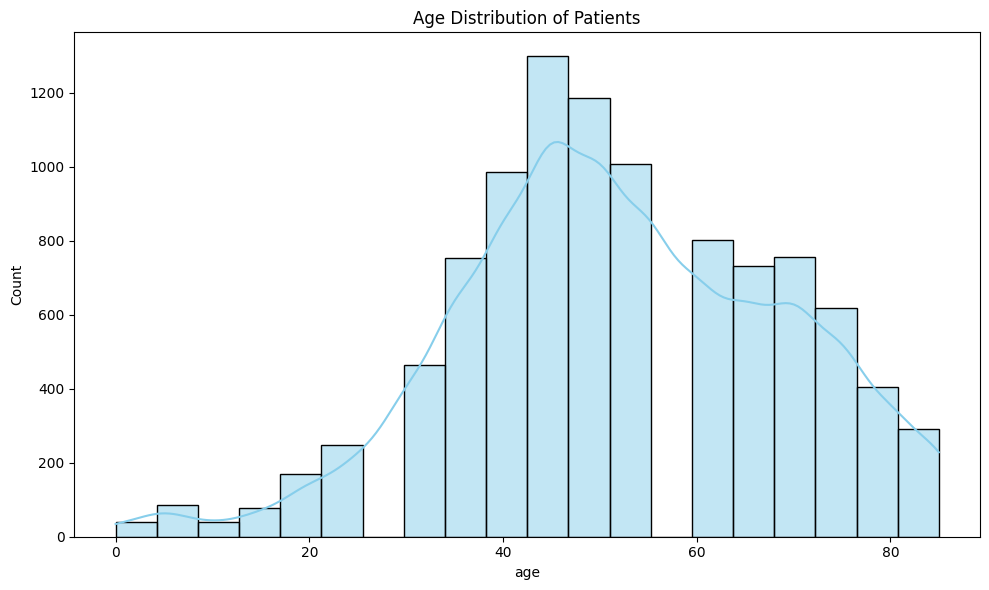

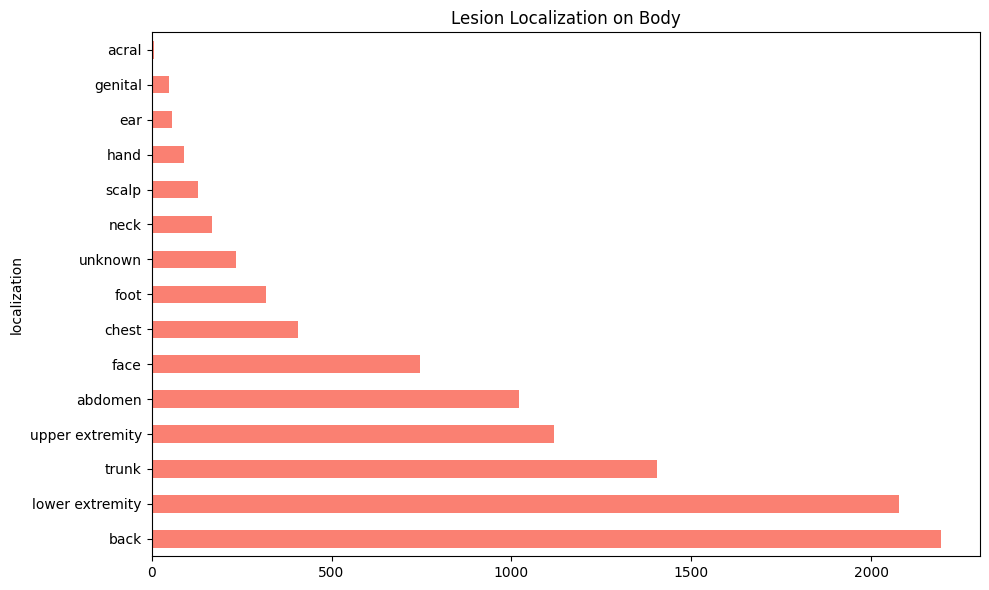

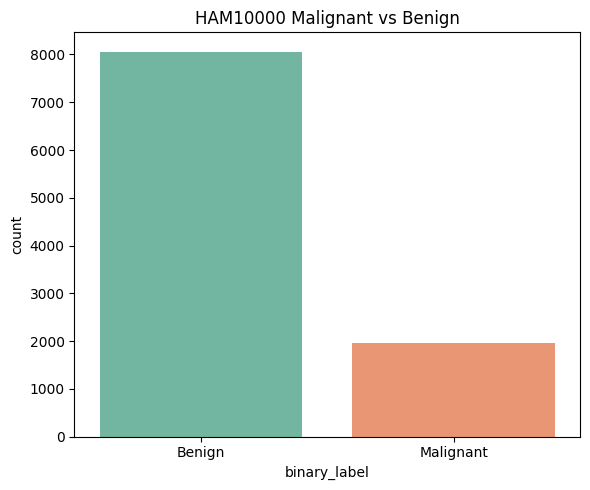



---- ISIC 2019 Summary ----
Total Images: 25331

Class Counts:
cell_type
Melanocytic Nevus          12875
Melanoma                    4522
Basal Cell Carcinoma        3323
Benign Keratosis            2624
Actinic Keratosis            867
Squamous Cell Carcinoma      628
Vascular Lesion              253
Dermatofibroma               239
Name: count, dtype: int64
------------------------



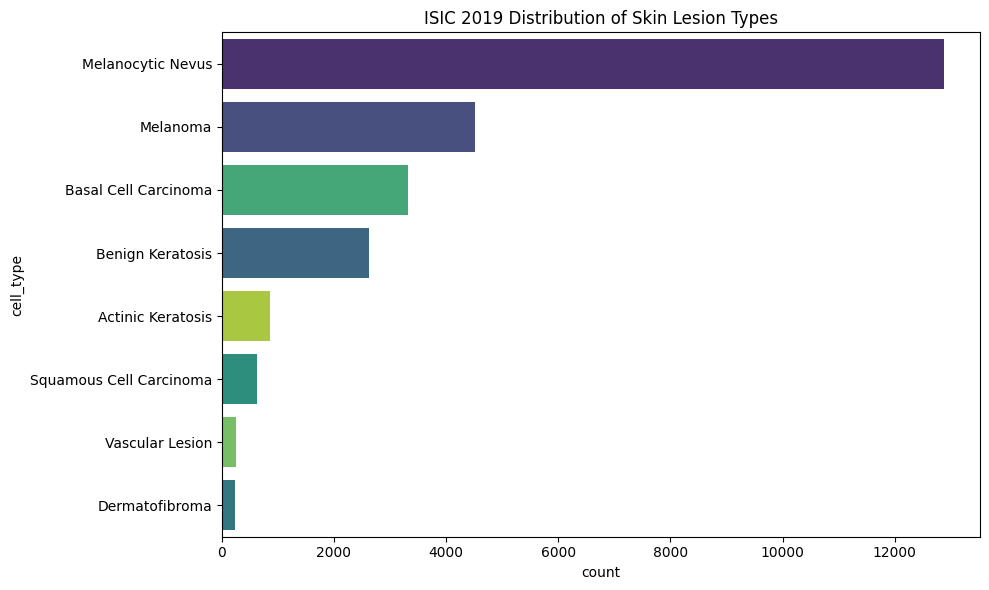

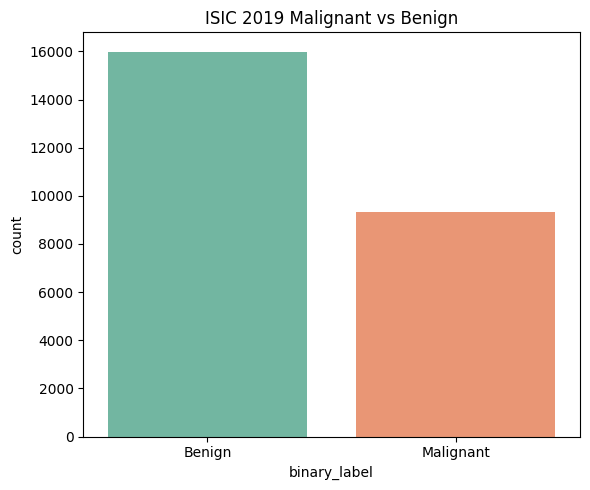

In [27]:
#exploratory data analysis VERSION 2 WITH HAM10000 & ISIC
#distribution and information about HAM10000 & ISIC
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs('/content/skin-lesion-classifier/EDA', exist_ok=True)

#HAM10000
metadata = '/content/skin-lesion-classifier/data/ham10000/HAM10000_metadata.csv'
df = pd.read_csv(metadata)

labels = {
    'nv': 'Nevus',
    'mel': 'Melanoma',
    'bkl': 'Benign Keratosis',
    'bcc': 'Basal Cell Carcinoma',
    'akiec': 'Actinic Keratoses',
    'vasc': 'Vascular Lesions',
    'df': 'Dermatofibroma'
}
df['cell_type'] = df['dx'].map(labels)

#summary
print("---- HAM10000 Summary ----")
print(f"Total Images: {len(df)}")
print("\nClass Counts:")
print(df['cell_type'].value_counts())
print("\nTop 5 Localization Sites:")
print(df['localization'].value_counts().head(5))
print("------------------------\n")

# class distribution
plt.figure(figsize=(10,6))
sns.countplot(y='cell_type', data=df, order=df['cell_type'].value_counts().index, hue='cell_type', palette='viridis', legend=False)
plt.title('Distribution of Skin Lesion Types')
#so image doesnt clip/overlap with other elements and borders
plt.tight_layout()
plt.savefig('/content/skin-lesion-classifier/EDA/class_distribution.png')
plt.show()

# age distribution
plt.figure(figsize=(10,6))
sns.histplot(df['age'].dropna(), bins=20, kde=True, color='skyblue')
plt.title('Age Distribution of Patients')
plt.tight_layout()
plt.savefig('/content/skin-lesion-classifier/EDA/age_distribution.png')
plt.show()

# skin lesion localization distribution
plt.figure(figsize=(10,6))
df['localization'].value_counts().plot(kind='barh', color='salmon')
plt.title('Lesion Localization on Body')
plt.tight_layout()
plt.savefig('/content/skin-lesion-classifier/EDA/localization.png')
plt.show()

#malignant vs benign breakdown
malignant = ['Melanoma', 'Basal Cell Carcinoma', 'Actinic Keratoses']
df['binary_label'] = df['cell_type'].apply(lambda x: 'Malignant' if x in malignant else 'Benign')

plt.figure(figsize=(6,5))
sns.countplot(x='binary_label', data=df, hue='binary_label', palette='Set2', legend=False)
plt.title('HAM10000 Malignant vs Benign')
plt.tight_layout()
plt.savefig('/content/skin-lesion-classifier/EDA/ham_malignant_vs_benign.png')
plt.show()

#ISIC 2019, doesnt have much metadata about patients. just lesions.
isic_metadata = '/content/skin-lesion-classifier/data/isic2019/ISIC_2019_Training_GroundTruth.csv'
isic_df = pd.read_csv(isic_metadata)

isic_labels = {
    'MEL': 'Melanoma',
    'NV': 'Melanocytic Nevus',
    'BCC': 'Basal Cell Carcinoma',
    'AK': 'Actinic Keratosis',
    'BKL': 'Benign Keratosis',
    'DF': 'Dermatofibroma',
    'VASC': 'Vascular Lesion',
    'SCC': 'Squamous Cell Carcinoma'
}

#convert one-hot encoding back to a single class column
isic_df['cell_type'] = isic_df[list(isic_labels.keys())].idxmax(axis=1).map(isic_labels)

#summary
print("\n\n---- ISIC 2019 Summary ----")
print(f"Total Images: {len(isic_df)}")
print("\nClass Counts:")
print(isic_df['cell_type'].value_counts())
print("------------------------\n")

# class distribution
plt.figure(figsize=(10,6))
sns.countplot(y='cell_type', data=isic_df, order=isic_df['cell_type'].value_counts().index, hue='cell_type', palette='viridis', legend=False)
plt.title('ISIC 2019 Distribution of Skin Lesion Types')
plt.tight_layout()
plt.savefig('/content/skin-lesion-classifier/EDA/isic_class_distribution.png')
plt.show()

#malignant vs benign breakdown
isic_malignant = ['MEL', 'BCC', 'AK', 'SCC']
isic_df['binary_label'] = isic_df[isic_malignant].max(axis=1).map({1: 'Malignant', 0: 'Benign'})

plt.figure(figsize=(6,5))
sns.countplot(x='binary_label', data=isic_df, hue='binary_label', palette='Set2', legend=False)
plt.title('ISIC 2019 Malignant vs Benign')
plt.tight_layout()
plt.savefig('/content/skin-lesion-classifier/EDA/isic_malignant_vs_benign.png')
plt.show()

In [28]:
#classify diagnosis into malignant or benign. sorting the dataset into train, val, and test
!python /content/skin-lesion-classifier/source/classify_data.py

shell-init: error retrieving current directory: getcwd: cannot access parent directories: No such file or directory
shell-init: error retrieving current directory: getcwd: cannot access parent directories: No such file or directory
HAM10000 Benign and Malignant class counts:
Benign is 0, Malignant is 1
binary_label
0    8061
1    1954
Name: count, dtype: int64

Sorting train data...
Sorting validation data...
Sorting test data...

Train size: 8012
Validation size: 1001
Test size: 1002

ISIC 2019 Malignant class counts:
MEL    4522.0
BCC    3323.0
AK      867.0
SCC     628.0
dtype: float64

Sorting ISIC 2019 train data...
Sorting ISIC 2019 validation data...
Sorting ISIC 2019 test data...

ISIC Train size: 7472
ISIC Validation size: 934
ISIC Test size: 934


In [ ]:
# ALBUMENTATIONS (final version)
# THE ONE WITHOUT ALBUMENTATION FOR USER INPUT HAS A CLOSER/HIGHER PERCENTAGE/CONFIDENCE LEVEL (RUN & TEST TO SEE) THAN THE ONE WITH ALBUMENTATION

import torch
import timm
import numpy as np
import cv2
import os
import time
import albumentations as A
from albumentations.pytorch import ToTensorV2
from PIL import Image

# setup device and model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# change this path if needed

model_path = '/content/skin-lesion-classifier/models/efficientnetb4-v3/efficientnet_b4_v3_epoch_25.pth'

# initialize efficientnet-b4 architecture
model = timm.create_model('efficientnet_b4', pretrained=False, num_classes=2)

if os.path.exists(model_path):
    try:
        model.load_state_dict(torch.load(model_path, map_location=device))
        model = model.to(device).eval()
        print(f"Model loaded successfully on {device}.\n")
    except Exception as e:
        print(f"RuntimeError: {e}")
        print("Note: If 'central directory' error persists, delete and re-upload the .pth file.")
else:
    print(f"ERROR: Model not found at {model_path}")

# standard transform for normal testing
base_transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

# tta pipeline using albumentations (more advanced medical distortions)
# we use 8 different views to get a better average
tta_pipeline = [
    base_transform,
    A.Compose([A.Resize(224, 224), A.HorizontalFlip(p=1.0), A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]), ToTensorV2()]),
    A.Compose([A.Resize(224, 224), A.VerticalFlip(p=1.0), A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]), ToTensorV2()]),
    A.Compose([A.Resize(224, 224), A.RandomRotate90(p=1.0), A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]), ToTensorV2()]),
    A.Compose([A.Resize(224, 224), A.ColorJitter(brightness=0.2, contrast=0.2, p=1.0), A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]), ToTensorV2()]),
    A.Compose([A.Resize(224, 224), A.GridDistortion(p=1.0), A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]), ToTensorV2()]),
    A.Compose([A.Resize(224, 224), A.OpticalDistortion(distort_limit=0.1, p=1.0), A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]), ToTensorV2()]),
    A.Compose([A.Resize(224, 224), A.GaussNoise(var_limit=(10.0, 50.0), p=1.0), A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]), ToTensorV2()])
]

# load image using opencv for albumentations compatibility
def preprocess_image(image_path):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img

# run one prediction pass
def get_prediction(img_numpy, transform_pipeline):
    augmented = transform_pipeline(image=img_numpy)["image"]
    tensor = augmented.unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(tensor)
        probs = torch.softmax(output, dim=1).squeeze().cpu().numpy()
    return probs

# main classify function with tta
def classify(image_path):
    if not os.path.isfile(image_path):
        print(f"[ERROR] File not found: {image_path}")
        return

    # load image as numpy
    img_np = preprocess_image(image_path)

    # get standard prediction
    std_probs = get_prediction(img_np, base_transform)

    # get tta predictions (average of 8 views)
    tta_results = []
    for t in tta_pipeline:
        tta_results.append(get_prediction(img_np, t))
    avg_tta_probs = np.mean(tta_results, axis=0)

    # results display
    print("\n" + "─" * 40)
    print(f"File : {os.path.basename(image_path)}")
    print("─" * 40)

    # helper for printing labels
    for label_header, probs in [("Without Albumentation", std_probs), (f"With TTA ({len(tta_pipeline)} Averaged)", avg_tta_probs)]:
        pred_idx = np.argmax(probs)
        label = "Malignant" if pred_idx == 1 else "Benign"

        print(f"[{label_header}]")
        print(f"Prediction  : {label}")
        print("\nConfidence Scores: ")
        print(f"Benign      : {probs[0]*100:.2f}%")
        print(f"Malignant   : {probs[1]*100:.2f}%")
        print("─" * 40)

    print("NOTE: For research use and testing only.")
    print("─" * 40 + "\n")

# start input loop
if __name__ == "__main__":
    if os.name == 'nt':
          # Command for Windows
          _ = os.system('cls')
    else:
          # Command for Linux and macOS
          _ = os.system('clear')
    while True:
        path = input("Enter image path (or 'q' to quit): ").strip()
        if path.lower() in ("q", "quit", "exit"):
            print("Exiting.")
            break
        classify(path)

/tmp/ipykernel_796/4001488703.py:52: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.Compose([A.Resize(224, 224), A.GaussNoise(var_limit=(10.0, 50.0), p=1.0), A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]), ToTensorV2()])


Model loaded successfully on cuda.

Enter image path (or 'q' to quit): /content/skin-lesion-classifier/user_test_images/malignant_test1.jpg

────────────────────────────────────────
File : malignant_test1.jpg
────────────────────────────────────────
[Without Albumentation]
Prediction  : Malignant

Confidence Scores: 
Benign      : 0.00%
Malignant   : 100.00%
────────────────────────────────────────
[With TTA (8 Averaged)]
Prediction  : Malignant

Confidence Scores: 
Benign      : 0.12%
Malignant   : 99.88%
────────────────────────────────────────
NOTE: For research use and testing only.
────────────────────────────────────────

Enter image path (or 'q' to quit): /content/skin-lesion-classifier/user_test_images/malignant_test2.jpg

────────────────────────────────────────
File : malignant_test2.jpg
────────────────────────────────────────
[Without Albumentation]
Prediction  : Malignant

Confidence Scores: 
Benign      : 0.96%
Malignant   : 99.04%
────────────────────────────────────────

Report on: efficientnet_b4_v1_epoch_20.pth
────────────────────────────────────────────────────────────
Standard Evaluation...

[ CORE PERFORMANCE ]
Validation Loss : 1.1044
Accuracy        : 70.06%
F1 Score        : 0.6731
Recall (Sens)   : 0.5320
Precision       : 0.9163
AU-ROC Score    : 0.8841
Avg Precision   : 0.9092

[ SENSITIVITY AT FIXED CAPACITY ]
FPR Target     : 10.0%
Sensitivity    : 0.5986

MC Dropout Analysis (10 samples)...

[ MC DROPOUT UNCERTAINTY ]
Mean Variance : 0.008477

Generating Visual Dashboards...


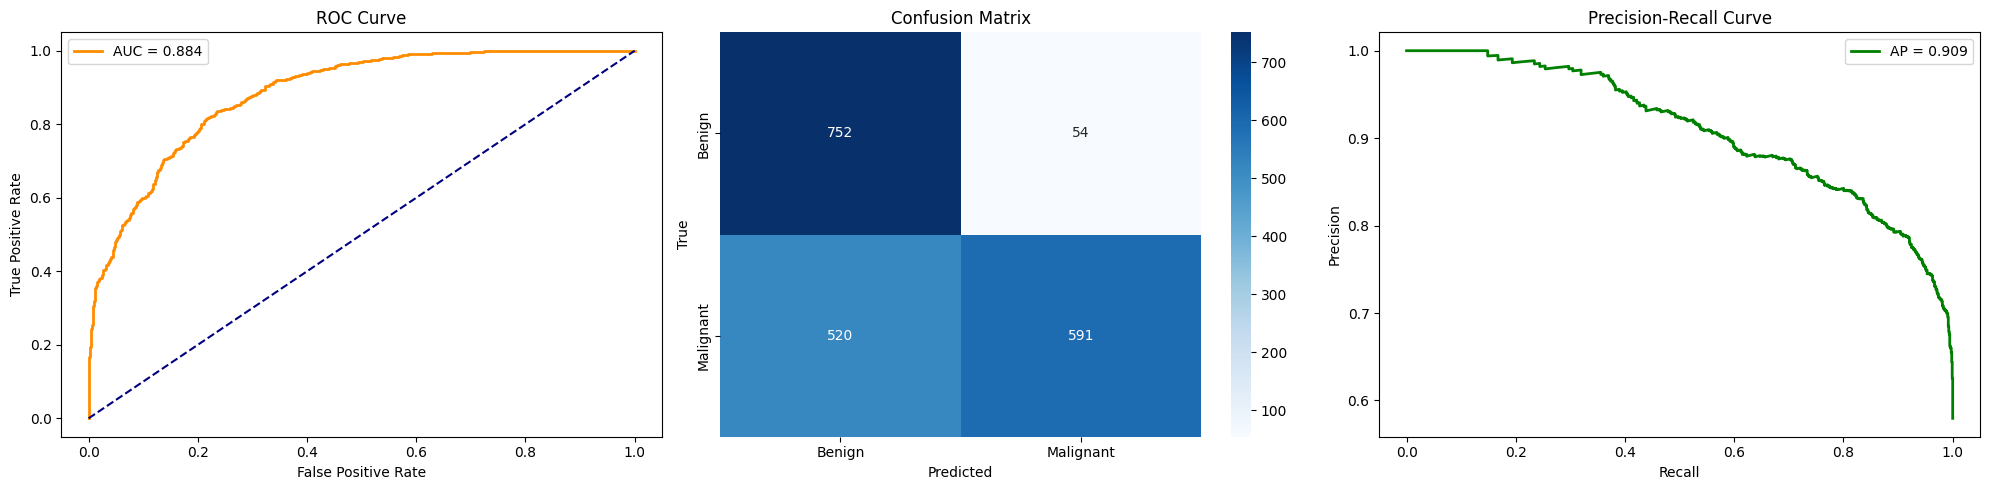


DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Benign       0.59      0.93      0.72       806
   Malignant       0.92      0.53      0.67      1111

    accuracy                           0.70      1917
   macro avg       0.75      0.73      0.70      1917
weighted avg       0.78      0.70      0.69      1917



In [40]:
# Metrics: Val Loss, Acc, F1, Precision, Recall, AU-ROC, CM,
# Sensitivity, MC Dropout, Precision-Recall Curve

import torch
import torch.nn as nn
import timm
import numpy as np
import sys
import os
import cv2
import seaborn as sns
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import datasets
from sklearn.metrics import (f1_score, accuracy_score, recall_score,
                             precision_score, confusion_matrix,
                             roc_auc_score, roc_curve, classification_report,
                             precision_recall_curve, average_precision_score)

#directory
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), 'source')))
from source.augment_data import val_transforms

#device set up
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

#paths
val_dir = '/content/skin-lesion-classifier/data/model_data/val'
model_path = '/content/skin-lesion-classifier/models/efficientnetb4-v1/efficientnet_b4_v1_epoch_20.pth'

class AlbuImageFolder(datasets.ImageFolder):
    def __getitem__(self, index):
        path, target = self.samples[index]
        image = cv2.imread(path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        if self.transform is not None:
            augmented = self.transform(image=image)
            image = augmented['image']
        return image, target

#validation data
val_dataset = AlbuImageFolder(val_dir, transform=val_transforms)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

#initialize model
model = timm.create_model('efficientnet_b4', pretrained=False, num_classes=2)
model.load_state_dict(torch.load(model_path, map_location=device))
model = model.to(device)
criterion = nn.CrossEntropyLoss()

def run_master_audit():
    if not os.path.exists(model_path):
        print(f"ERROR: Model file not found at {model_path}")
        return

    print(f"Report on: {os.path.basename(model_path)}")
    print("─" * 60)

    #evaluation
    model.eval()
    all_preds, all_probs, all_labels = [], [], []
    val_loss = 0.0

    print("Standard Evaluation...")
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

            all_probs.extend(probs[:, 1].cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    #peformance metrics
    avg_val_loss = val_loss / len(val_loader)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds)
    auroc = roc_auc_score(all_labels, all_probs)
    ap_score = average_precision_score(all_labels, all_probs)

    print("\n[ CORE PERFORMANCE ]")
    print(f"Validation Loss : {avg_val_loss:.4f}")
    print(f"Accuracy        : {acc*100:.2f}%")
    print(f"F1 Score        : {f1:.4f}")
    print(f"Recall (Sens)   : {recall:.4f}")
    print(f"Precision       : {prec:.4f}")
    print(f"AU-ROC Score    : {auroc:.4f}")
    print(f"Avg Precision   : {ap_score:.4f}")

    #sensitivity
    target_fpr = 0.10
    fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
    fixed_sens = np.interp(target_fpr, fpr, tpr)

    print("\n[ SENSITIVITY AT FIXED CAPACITY ]")
    print(f"FPR Target     : {target_fpr*100}%")
    print(f"Sensitivity    : {fixed_sens:.4f}")

    # mc dropout
    print("\nMC Dropout Analysis (10 samples)...")

    # Force model into train mode
    model.train()
    for m in model.modules():
        if isinstance(m, nn.BatchNorm2d):
            m.eval()

    if hasattr(model, 'classifier'):
        original_dropout = model.classifier
        # Inject a temporary 20% Dropout layer for the audit
        model.classifier = nn.Sequential(
            nn.Dropout(p=0.2, inplace=False),
            original_dropout
        )

    mc_samples = 10
    mc_results = []

    with torch.no_grad():
        for _ in range(mc_samples):
            pass_probs = []
            for images, _ in val_loader:
                outputs = model(images.to(device))
                pass_probs.extend(torch.softmax(outputs, dim=1)[:, 1].cpu().numpy())
            mc_results.append(pass_probs)

    if hasattr(model, 'classifier'):
        model.classifier = original_dropout
    model.eval()

    mc_results = np.array(mc_results)
    uncertainty = np.var(mc_results, axis=0)

    print("\n[ MC DROPOUT UNCERTAINTY ]")
    print(f"Mean Variance : {np.mean(uncertainty):.6f}")

    #graphs
    print("\nGenerating Visual Dashboards...")
    fig, ax = plt.subplots(1, 3, figsize=(20, 5))

    # ROC Curve
    ax[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {auroc:.3f}')
    ax[0].plot([0, 1], [0, 1], color='navy', linestyle='--')
    ax[0].set_title('ROC Curve')
    ax[0].set_xlabel('False Positive Rate')
    ax[0].set_ylabel('True Positive Rate')
    ax[0].legend()

    # confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[1],
                xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
    ax[1].set_title('Confusion Matrix')
    ax[1].set_xlabel('Predicted')
    ax[1].set_ylabel('True')

    # precision-recall curve
    p, r, _ = precision_recall_curve(all_labels, all_probs)
    ax[2].plot(r, p, color='green', lw=2, label=f'AP = {ap_score:.3f}')
    ax[2].set_title('Precision-Recall Curve')
    ax[2].set_xlabel('Recall')
    ax[2].set_ylabel('Precision')
    ax[2].legend()

    plt.tight_layout()
    plt.show()

    print("\n" + "="*40)
    print("DETAILED CLASSIFICATION REPORT")
    print("="*40)
    print(classification_report(all_labels, all_preds, target_names=['Benign', 'Malignant']))

if __name__ == "__main__":
    run_master_audit()

/content/skin-lesion-classifier/source/augment_data.py:31: UserWarning: Argument(s) 'shift_limit' are not valid for transform OpticalDistortion
  A.OpticalDistortion(distort_limit=0.1, shift_limit=0.1, p=0.5),
/content/skin-lesion-classifier/source/augment_data.py:36: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 50.0), p=0.2),


Augmentation sample saved as 'augmentation_samples.png'


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

Starting Training with Combined Dataset for 30 Epochs...
Epoch [1/30] - Train Loss: 0.4579 | Val Loss: 0.3649 | Val Acc: 0.8310 | Val F1: 0.8370 | Recall: 0.7489 | Prec: 0.9487


KeyboardInterrupt: 

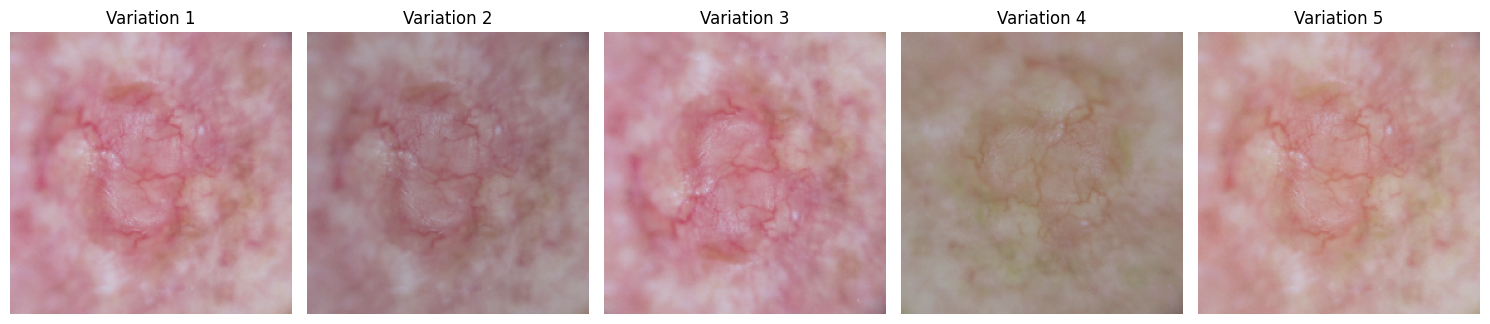

In [ ]:
# DO NOT RUN THIS
# VERSION 2 ALBUMENTATIONS
# if you are getting errors, run the gitclone (first code block) and only run this code block
# efficientnet-b4 (Albumentations + Weighted Sampling + AdamW)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler, Dataset
from torchvision import datasets
import timm
import numpy as np
import cv2
import sys
import os
from sklearn.metrics import f1_score, accuracy_score, recall_score, precision_score

# directory validation
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), 'source')))
# assuming your augment_data.py now contains the Albumentations versions
from source.augment_data import train_transforms, val_transforms

# custom dataset class because Albumentations needs NumPy/OpenCV inputs
class AlbumentationsDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.data = datasets.ImageFolder(root_dir)
        self.transform = transform

    def __getitem__(self, index):
        path, label = self.data.samples[index]
        # load image with opencv for albumentations compatibility
        image = cv2.imread(path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.transform:
            augmented = self.transform(image=image)
            image = augmented['image']

        return image, label

    def __len__(self):
        return len(self.data)

# device configuration for better performance
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# folders containing combined HAM10000 and ISIC (Malignant-only) data
train_dir = '/content/skin-lesion-classifier/data/model_data/train'
val_dir = '/content/skin-lesion-classifier/data/model_data/val'

# applying the custom dataset with albumentations
train_dataset = AlbumentationsDataset(train_dir, transform=train_transforms)
val_dataset = AlbumentationsDataset(val_dir, transform=val_transforms)

# weightedrandomsampler for the imbalance (balances malignant/benign in batches)
# this looks at the combined counts of both datasets
target = np.array(train_dataset.data.targets)
class_sample_count = np.array([len(np.where(target == t)[0]) for t in np.unique(target)])
sampler_weights = 1. / class_sample_count
samples_weight = np.array([sampler_weights[t] for t in target])
sampler = WeightedRandomSampler(torch.from_numpy(samples_weight), len(samples_weight))

# data loaders - using batch size 16 for efficientnet-b4 memory limits
train_loader = DataLoader(train_dataset, batch_size=16, sampler=sampler, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

# efficientNet-B4 - pretrained and modified for 2 classes
model = timm.create_model('efficientnet_b4', pretrained=True, num_classes=2)
model = model.to(device)

# loss weights - using square root class weights for better precision/recall balance
loss_weights = 1. / np.sqrt(class_sample_count)
weights_tensor = torch.FloatTensor(loss_weights).to(device)
criterion = nn.CrossEntropyLoss(weight=weights_tensor)

# adamW - learning rate and weight decay optimized for stability
optimizer = optim.AdamW(model.parameters(), lr=0.0002, weight_decay=0.01)

# learning rate scheduler to reduce LR when Val Loss plateaus
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)

# training loop
num_epochs = 30
print(f"Starting Training with Combined Dataset for {num_epochs} Epochs...")

for epoch in range(num_epochs):
    # training phase
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)

    # validation phase
    model.eval()
    all_preds = []
    all_labels = []
    val_loss = 0.0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # evaluation metrics to track precision/recall and accuracy baseline
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds)

    avg_val_loss = val_loss / len(val_loader)
    scheduler.step(avg_val_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {acc:.4f} | Val F1: {f1:.4f} | Recall: {recall:.4f} | Prec: {precision:.4f}")

    # save the model state every 5 epochs
    if (epoch + 1) % 5 == 0:
        torch.save(model.state_dict(), f'efficientnet_b4_v3_epoch_{epoch+1}.pth')

# final save
torch.save(model.state_dict(), 'efficientnet_b4_v3_baseline_final.pth')
print("Training Complete. Combined models saved.")